In [1]:
import shutil, os, pathlib
for p in [pathlib.Path.home()/".nv/ComputeCache",
          pathlib.Path.home()/".cache/jax",
          pathlib.Path.home()/".cache/xla"]:
    shutil.rmtree(p, ignore_errors=True)
print("caches cleared; restart kernel and re-run the first cell.")

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("JAX_PLATFORMS", "cuda")
os.environ.setdefault("JAX_ENABLE_X80", "True")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "True"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.65" 

import jax, jax.numpy as jnp

import os, sys
os.chdir("/home/agnes/Skyclean")       # repo root
sys.path.insert(0, os.getcwd())

from skyclean.silc.ilc import ProduceSILC
from skyclean.silc.ilc import SILCTools
from skyclean.silc.file_templates import FileTemplates
from skyclean.silc.pipeline import Pipeline
from skyclean.silc.power_spec import MapAlmConverter, PowerSpectrumTT
from skyclean.silc.map_tools import SamplingConverters, MWTools  
from skyclean.silc.download import DownloadData
from skyclean.silc.harmonic_response import HRFigures, HarmonicWindows, AxisymmetricGenerators, SimpleHarmonicWindows
from skyclean.silc.custom_s2wav_bandlimits import j_max_silc

directory = "/Scratch/agnes/data" 
ft = FileTemplates(directory).file_templates

# INPUT wavelet coeff template (uses {comp}, {frequency}, {scale}, {realisation:05d}, {lmax}, {lam})
file_template = ft.get("wavelet_coeffs") or ft["wavelet_c_j"]

# OUTPUT templates expected by ILC_wav_coeff_maps_MP (use {component}, {extract_comp}, {realisation})
output_templates = {
    "doubled_maps":           ft["doubled_maps"],
    "covariance_matrices":    ft["covariance_matrices"],
    "weight_vector_matrices": ft["weight_vector_matrices"],
    "ilc_maps":               ft["ilc_maps"],
    "trimmed_maps":           ft["trimmed_maps"],
    "ilc_synth":              ft["ilc_synth"],
    "ilc_spectrum":           ft.get("ilc_spectrum"),  
    "scaling_coeffs":         ft["scaling_coeffs"], 
    "f_scal":                 ft["f_scal"],
}

if __name__ == "__main__":                    
    import multiprocessing as mp
    mp.set_start_method("spawn", force=True) 

caches cleared; restart kernel and re-run the first cell.


In [ ]:
pipe = Pipeline(
    components = [
     'cmb',
     "noise",
     "tsz",
    ],
    wavelet_components=["cfn"],
    ilc_components=['cmb'],              
    frequencies=["030","044","070","100","143","217","353","545","857"],
    realisations=1,
    start_realisation=0,
    lmax=300,
    N_directions=1,
    lam=2.0,
    method="jax_cuda",
    visualise=True,
    save_ilc_intermediates=True,
    overwrite=True,
    directory="/Scratch/agnes/data",
    constraint=False,
    nsamp=1200,

    # ---- pcILC ----
    pcilc=False,
    pcilc_component="cmb",                
    pcilc_eps=0.05,                    
    pcilc_pick="minvar",

    # ---- topo ----
    topology=None,
    )

In [8]:
pipe = Pipeline(
    components=["real"],
    wavelet_components=["real"],
    ilc_components=["cmb"],
    frequencies=[
        "030",
        "044",
        "070",
        "100",
        "143",
        "217",
        "353",
        "545",
        "857",
    ],

    realisations=1,
    start_realisation=0,

    lmax=300,
    N_directions=4,
    lam=2.0,

    method="jax_cuda",
    visualise=True,
    save_ilc_intermediates=True,
    overwrite=True,
    directory="/Scratch/agnes/data",

    constraint=False,
    nsamp=1200,

    # ---- pcILC ----
    pcilc=False,
    pcilc_component="cmb",
    pcilc_eps=0.05,
    pcilc_pick="minvar",

    # ---- topo ----
    topology=None,
)

In [3]:
pipe.step_download()

--- STARTING DATA DOWNLOAD ---
Device 0: bytes_in_use=0 peak_bytes_in_use=0 bytes_limit=19069206528 largest_free_chunk=n/a num_allocs=0
File /Scratch/agnes/data/CMB_realisations/real_f030.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f044.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f070.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f100.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f143.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f217.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f353.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data/CMB_realisations/real_f545.fits already exists and is valid. Skipping download.
File /Scratch/agnes/data

In [9]:
pipe.step_process()

--- PROCESSING CFNs AND TOTAL MAP CFN ---
Device 0: bytes_in_use=0 peak_bytes_in_use=448731136 bytes_limit=19069206528 largest_free_chunk=n/a num_allocs=1648112


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Processed real map at 030 GHz saved to /Scratch/agnes/data/processed_maps/processed_real_f030_lmax300.fits


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Processed real map at 044 GHz saved to /Scratch/agnes/data/processed_maps/processed_real_f044_lmax300.fits


...

Processed real map at 353 GHz saved to /Scratch/agnes/data/processed_maps/processed_real_f353_lmax300.fits


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Processed real map at 545 GHz saved to /Scratch/agnes/data/processed_maps/processed_real_f545_lmax300.fits


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Processed real map at 857 GHz saved to /Scratch/agnes/data/processed_maps/processed_real_f857_lmax300.fits


--- PRODUCING WAVELET TRANSFORMS ---
Device 0: bytes_in_use=0 peak_bytes_in_use=448731136 bytes_limit=19069206528 largest_free_chunk=n/a num_allocs=1648112


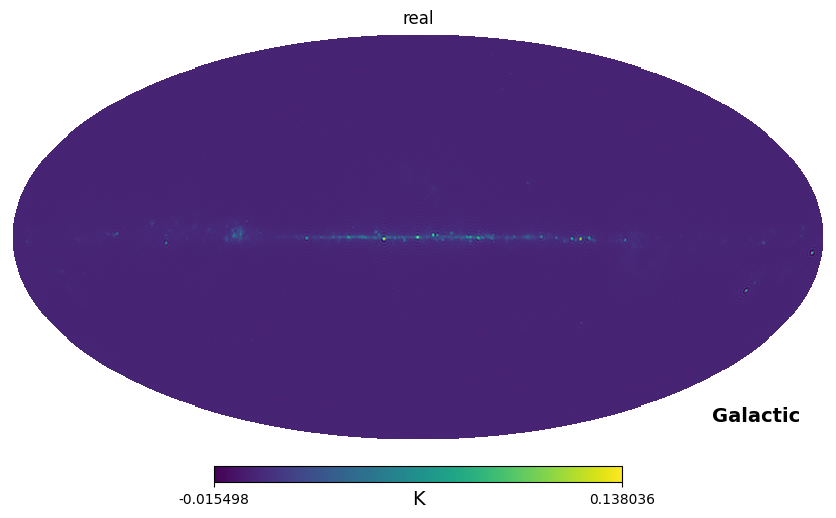

Wavelet transform for real at 030 GHz for realisation 0 saved.


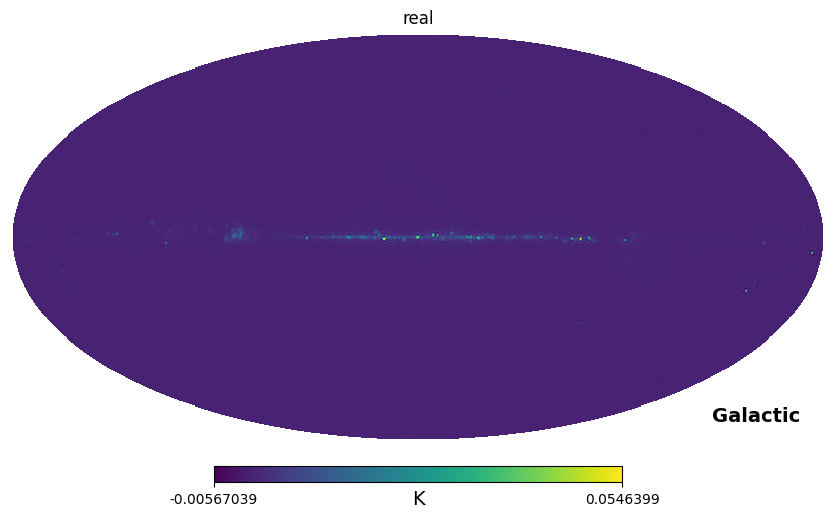

Wavelet transform for real at 044 GHz for realisation 0 saved.


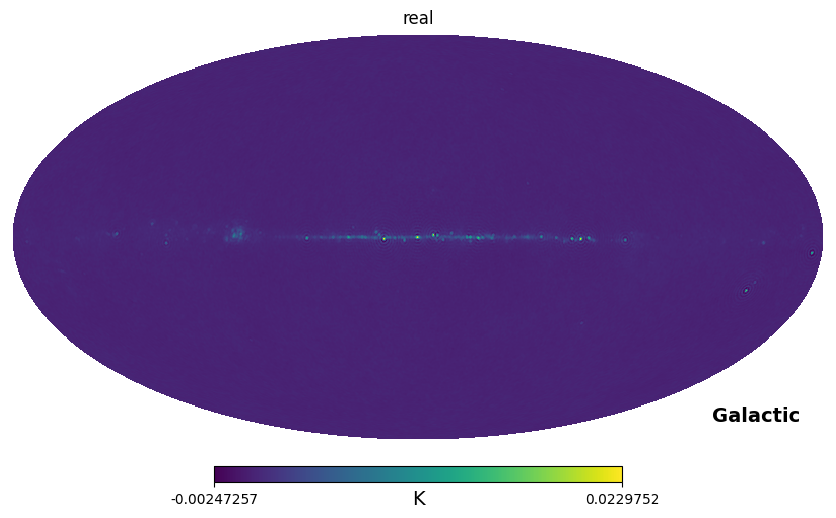

Wavelet transform for real at 070 GHz for realisation 0 saved.


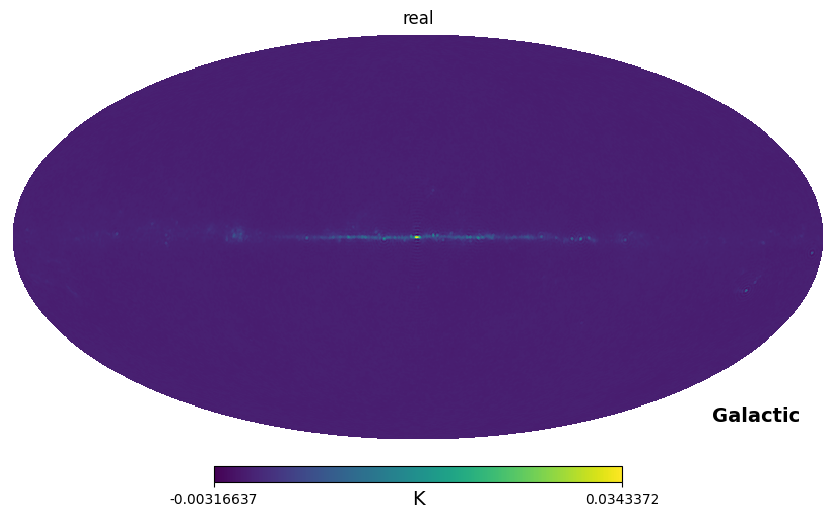

Wavelet transform for real at 100 GHz for realisation 0 saved.


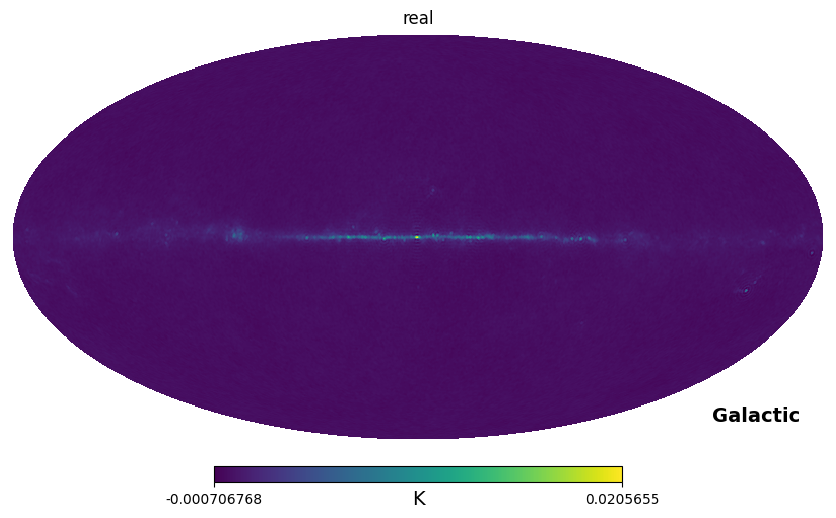

Wavelet transform for real at 143 GHz for realisation 0 saved.


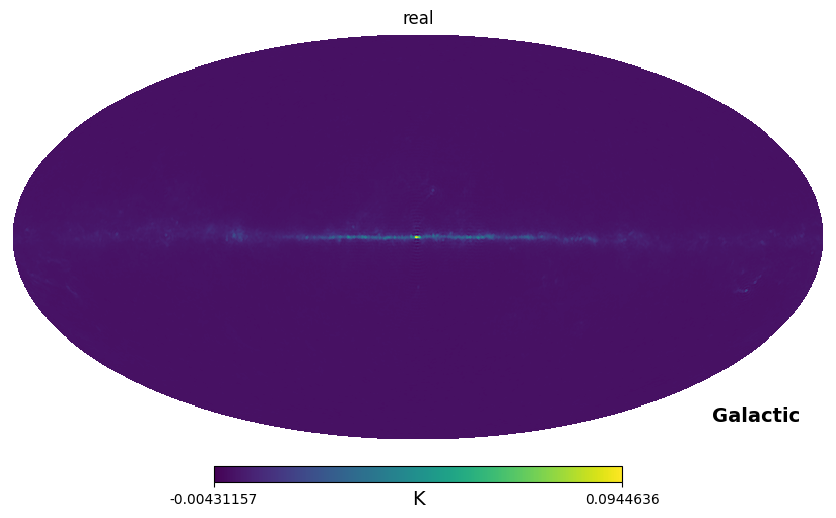

Wavelet transform for real at 217 GHz for realisation 0 saved.


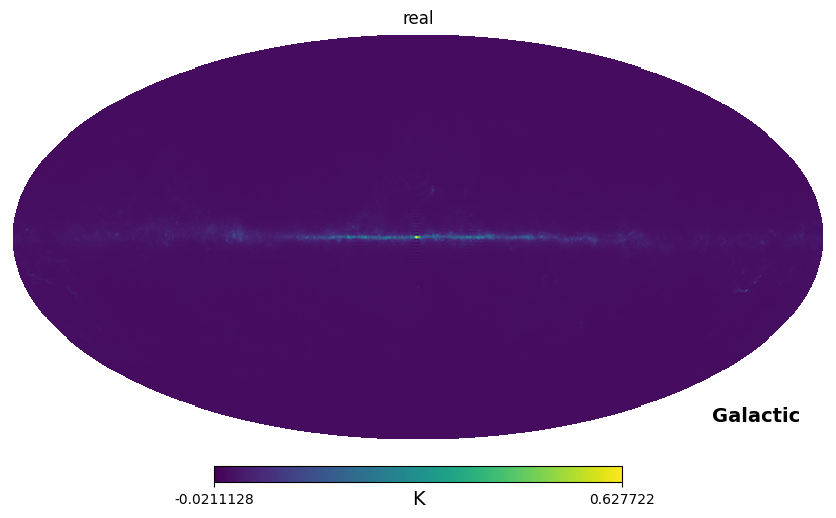

Wavelet transform for real at 353 GHz for realisation 0 saved.


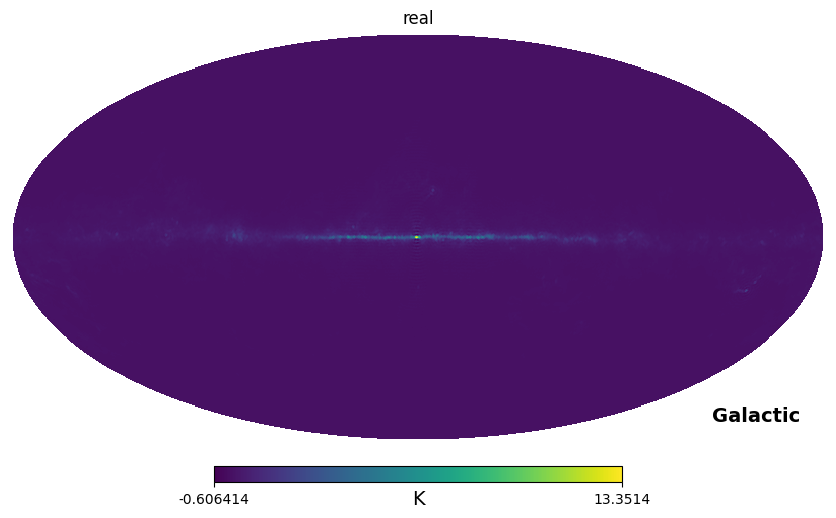

Wavelet transform for real at 545 GHz for realisation 0 saved.


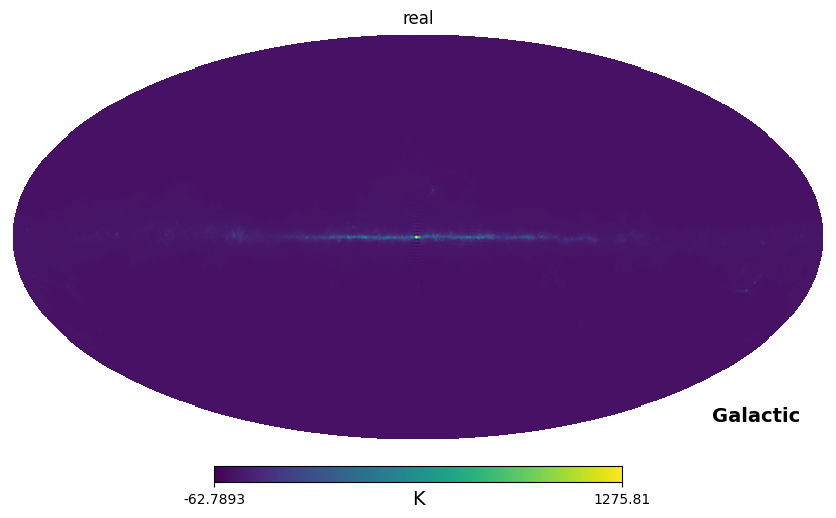

Wavelet transform for real at 857 GHz for realisation 0 saved.


In [10]:
pipe.step_wavelets()

--- RUNNING ILC (new functional API) ---
Device 0: bytes_in_use=0 peak_bytes_in_use=448731136 bytes_limit=19069206528 largest_free_chunk=n/a num_allocs=3284987
F_theory: [[ 1.00000000e+00 -1.87734280e+00]
 [ 1.00000000e+00 -1.82665801e+00]
 [ 1.00000000e+00 -1.68452266e+00]
 [ 1.00000000e+00 -1.44930766e+00]
 [ 1.00000000e+00 -1.00000000e+00]
 [ 1.00000000e+00 -8.05691485e-03]
 [ 1.00000000e+00  2.15206998e+00]
 [ 1.00000000e+00  5.37748967e+00]
 [ 1.00000000e+00  1.06543995e+01]]
--- ILC target='cmb'  input='real'  lmax=300  scales=[0, 1, 2, 3, 4, 5, 6, 7] ---
[DEBUG] passed L_max=301 -> L=301 lmax=300
[DEBUG] wavelet_js_custom(L)=[0, 1, 2, 3, 4, 5, 6, 7]
Derived Ndeproj=0
Processing realisation 0000 for component real
Doubled and saved wavelet maps in 35.47 seconds
Calculated covariance matrices in 404.85 seconds
Calculated weight vector matrices in 109.87 seconds
→ loading: /Scratch/agnes/data/SILC/weight_vector_data/real_weight_vector_cmb_s0_r0000_lmax300_N4_lam2.0_nsamp1200.npy
→ 

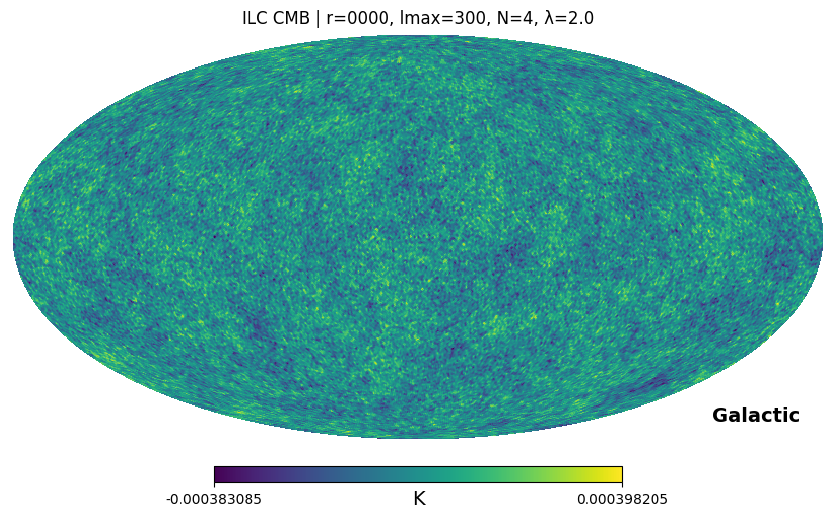

In [11]:
pipe.F_source = "theory"  # "empirical" or "theory"
pipe.F_kwargs = {
    "base_dir": os.path.join(pipe.directory, "CMB_realisations"),
    "frequencies": pipe.frequencies,
    "realization": pipe.start_realisation,  
    "normalize": True,
    "mask_path": "",
    "file_templates": {
        "cmb": "cmb_r{realisation:04d}.fits",
    },
}
pipe.step_ilc()

[DEBUG to_alm] source=ilc_synth component=real extract_comp=cmb constraint=False lmax=300 lam=2.0 nsamp=1200 freq=None freqs=['030', '044', '070', '100', '143', '217', '353', '545', '857']
              -> path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-real_f030_044_070_100_143_217_353_545_857_r0000_lmax300_N1_lam2.0_nsamp1200.npy
              -> exists=True


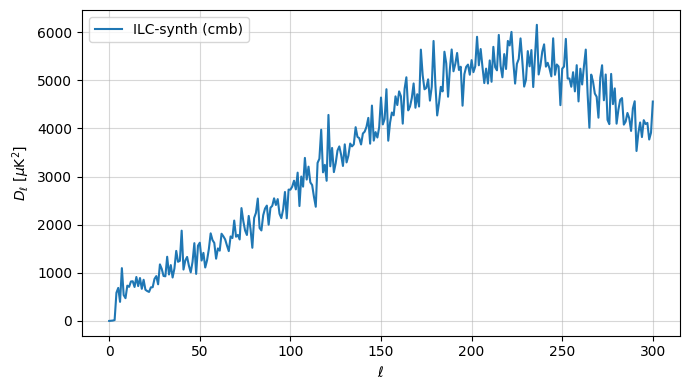

[DEBUG to_alm] source=ilc_synth component=real extract_comp=cmb constraint=False lmax=300 lam=2.0 nsamp=1200 freq=None freqs=['030', '044', '070', '100', '143', '217', '353', '545', '857']
              -> path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-real_f030_044_070_100_143_217_353_545_857_r0000_lmax300_N4_lam2.0_nsamp1200.npy
              -> exists=True


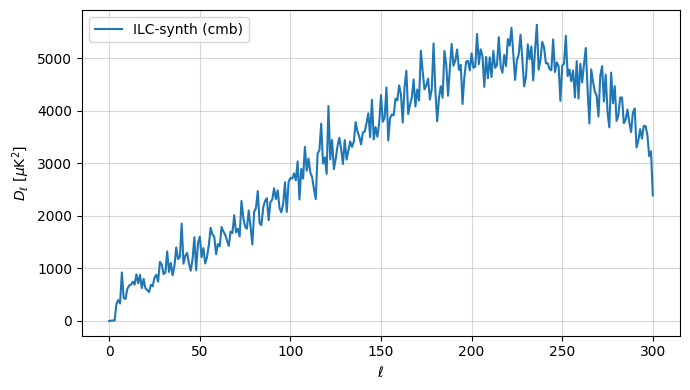

[DEBUG to_alm] source=processed component=cmb extract_comp=None constraint=None lmax=300 lam=None nsamp=None freq=143 freqs=None
              -> path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax300.npy
              -> exists=True


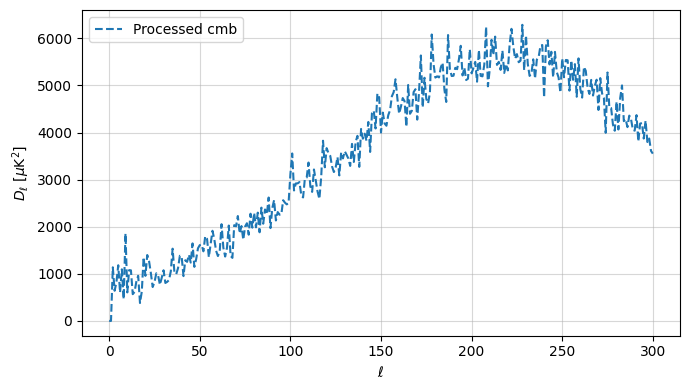

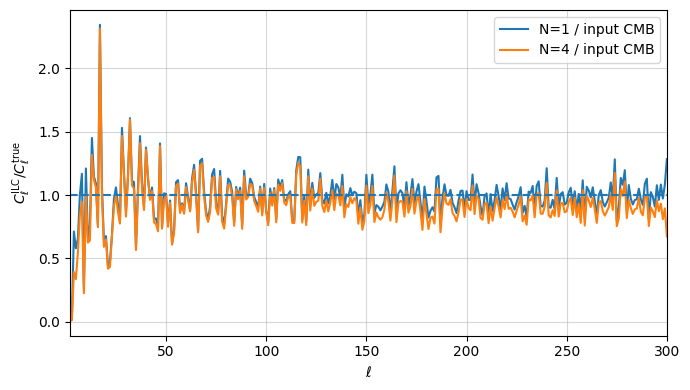

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# N = 1 ILC synth
# ==================================================

ell_N1, cl_N1 = pipe.step_power_spec(
    unit="K",
    source="ilc_synth",
    component="real",
    extract_comp="cmb",
    constraint=False,
    realisation=0,
    lmax=300,
    lam=2.0,
    N_directions=1,
    nsamp=1200,
)


# ==================================================
# N = 5 ILC synth
# ==================================================

ell_N2, cl_N2 = pipe.step_power_spec(
    unit="K",
    source="ilc_synth",
    component="real",
    extract_comp="cmb",
    constraint=False,
    realisation=0,
    lmax=300,
    lam=2.0,
    N_directions=4,
    nsamp=1200,
)


# ==================================================
# True input CMB
# ==================================================

ell_true, cl_true = pipe.step_power_spec(
    unit="K",
    source="processed",
    component="cmb",
    extract_comp=None,
    frequency="143",
    realisation=0,
    lmax=300,
    lam=2.0,
    nsamp=1200,
)


# ==================================================
# Match ell range
# ==================================================

ell_max = min(
    len(cl_N1),
    len(cl_N2),
    len(cl_true),
)

ell = ell_true[:ell_max]

cl_N1 = cl_N1[:ell_max]
cl_N4 = cl_N2[:ell_max]
cl_true = cl_true[:ell_max]


# ==================================================
# Compute ratios
# ==================================================

mask = (
    (ell >= 2)
    & np.isfinite(cl_true)
    & (cl_true != 0)
)

ratio_N1 = cl_N1[mask] / cl_true[mask]
ratio_N2 = cl_N2[mask] / cl_true[mask]


# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(7, 4))

plt.plot(
    ell[mask],
    ratio_N1,
    label="N=1 / input CMB",
)

plt.plot(
    ell[mask],
    ratio_N2,
    label="N=4 / input CMB",
)

plt.axhline(
    1.0,
    linestyle="--",
)

plt.xlim(2, 300)
#plt.ylim(0.60, 1.2)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\rm ILC} / C_\ell^{\rm true}$")

plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

[DEBUG to_alm] source=processed component=cmb extract_comp=None constraint=None lmax=256 lam=None nsamp=None freq=143 freqs=None
              -> path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy
              -> exists=True
[DEBUG to_alm] source=processed component=cmb extract_comp=None constraint=None lmax=256 lam=None nsamp=None freq=143 freqs=None
              -> path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy
              -> exists=True
[DEBUG xspec] X: Processed cmb fmt=hp path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy
[DEBUG xspec] Y: Processed cmb fmt=hp path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy


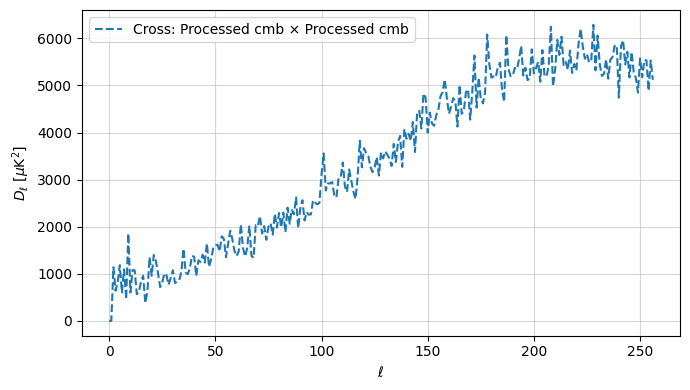

[DEBUG to_alm] source=ilc_synth component=cfn extract_comp=cmb constraint=False lmax=256 lam=2.0 nsamp=1200 freq=None freqs=['030', '044', '070', '100', '143', '217', '353', '545', '857']
              -> path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-cfn_f030_044_070_100_143_217_353_545_857_r0000_lmax256_N1_lam2.0_nsamp1200.npy
              -> exists=True


[DEBUG to_alm] source=processed component=cmb extract_comp=None constraint=None lmax=256 lam=None nsamp=None freq=143 freqs=None
              -> path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy
              -> exists=True
[DEBUG xspec] X: ILC-synth (cmb) fmt=mw path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-cfn_f030_044_070_100_143_217_353_545_857_r0000_lmax256_N1_lam2.0_nsamp1200.npy
[DEBUG xspec] Y: Processed cmb fmt=hp path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy


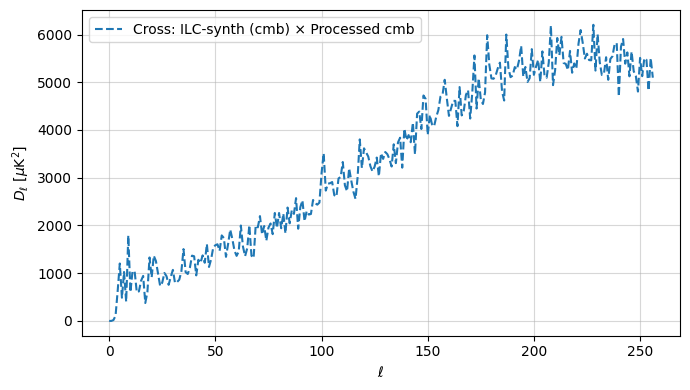

[DEBUG to_alm] source=ilc_synth component=cfn extract_comp=cmb constraint=False lmax=256 lam=2.0 nsamp=1200 freq=None freqs=['030', '044', '070', '100', '143', '217', '353', '545', '857']
              -> path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-cfn_f030_044_070_100_143_217_353_545_857_r0000_lmax256_N4_lam2.0_nsamp1200.npy
              -> exists=True
[DEBUG to_alm] source=processed component=cmb extract_comp=None constraint=None lmax=256 lam=None nsamp=None freq=143 freqs=None
              -> path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy
              -> exists=True
[DEBUG xspec] X: ILC-synth (cmb) fmt=mw path=/Scratch/agnes/data/SILC/ilc_synthesised_maps/ilc_cmb_from-cfn_f030_044_070_100_143_217_353_545_857_r0000_lmax256_N4_lam2.0_nsamp1200.npy
[DEBUG xspec] Y: Processed cmb fmt=hp path=/Scratch/agnes/data/processed_maps/processed_cmb_r0000_lmax256.npy


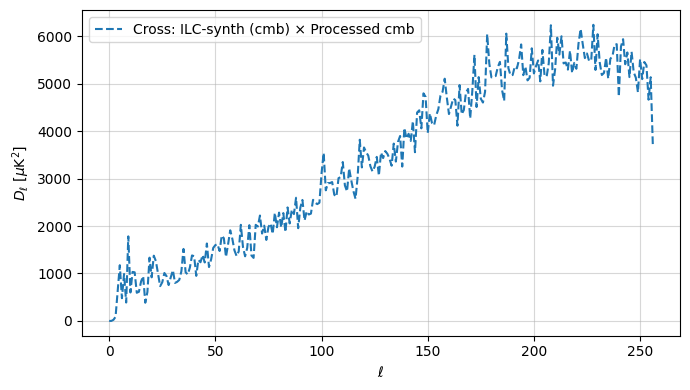

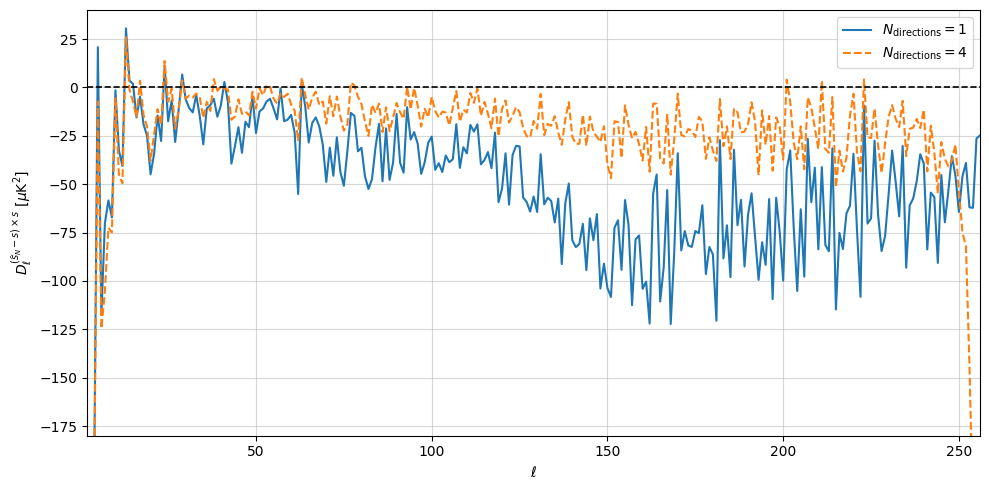

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# ==================================================
# Processed CMB auto-spectrum: common denominator
# ==================================================

ell_cmb, cl_cmb_auto = pipe.step_cross_power_spec(
    source_X="processed",
    component_X="cmb",
    frequency_X="143",

    source_Y="processed",
    component_Y="cmb",
    frequency_Y="143",

    realisation=0,
    lmax=256,
    lam=2.0,
    nsamp=1200,
    plot_r=False,
)


# ==================================================
# N_directions=1 ILC CMB x processed CMB
# ==================================================

ell_N1, cl_cross_N1 = pipe.step_cross_power_spec(
    source_X="ilc_synth",
    component_X="cfn",
    extract_comp_X="cmb",

    source_Y="processed",
    component_Y="cmb",
    frequency_Y="143",

    realisation=0,
    lmax=256,
    lam=2.0,
    N_directions=1,
    nsamp=1200,
    plot_r=False,
)


# ==================================================
# N_directions=4 ILC CMB x processed CMB
# ==================================================

ell_N4, cl_cross_N4 = pipe.step_cross_power_spec(
    source_X="ilc_synth",
    component_X="cfn",
    extract_comp_X="cmb",

    source_Y="processed",
    component_Y="cmb",
    frequency_Y="143",

    realisation=0,
    lmax=256,
    lam=2.0,
    N_directions=4,
    nsamp=1200,
    plot_r=False,
)


# ==================================================
# Check multipoles
# ==================================================

if not (
    np.array_equal(ell_cmb, ell_N1)
    and np.array_equal(ell_cmb, ell_N4)
):
    raise ValueError(
        "The CMB, N=1 and N=4 ell arrays do not match."
    )

# ==================================================
# Residual cross-spectra
#
# C_l^[(ILC_N - CMB) x CMB]
#   = C_l^[ILC_N x CMB] - C_l^[CMB x CMB]
# ==================================================

cl_residual_N1 = (
    cl_cross_N1
    - cl_cmb_auto
)

cl_residual_N4 = (
    cl_cross_N4
    - cl_cmb_auto
)


# Convert residual C_l to D_l in microkelvin^2
Dl_residual_N1 = (
    1e12
    * ell_cmb
    * (ell_cmb + 1)
    * cl_residual_N1
    / (2.0 * np.pi)
)

Dl_residual_N4 = (
    1e12
    * ell_cmb
    * (ell_cmb + 1)
    * cl_residual_N4
    / (2.0 * np.pi)
)


# ==================================================
# Valid multipoles
# ==================================================

valid = (
    (ell_cmb >= 2)
    & np.isfinite(Dl_residual_N1)
    & np.isfinite(Dl_residual_N4)
)


# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(10, 5))

plt.plot(
    ell_cmb[valid],
    Dl_residual_N1[valid],
    label=r"$N_{\rm directions}=1$",
)

plt.plot(
    ell_cmb[valid],
    Dl_residual_N4[valid],
    linestyle="--",
    label=r"$N_{\rm directions}=4$",
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

plt.xlabel(r"$\ell$")

plt.ylabel(
    r"$D_\ell^{(\widehat{s}_N-s)\times s}"
    r"\ [\mu{\rm K}^2]$"
)

plt.xlim(2, 256)
plt.ylim(-180,40)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()